TensorFlow version: 2.21.0
GPU available: []
Output directory: model
Found preprocessing? False
Running full preprocessing from raw DisGeNET...


100%|██████████| 26522/26522 [00:00<00:00, 32239.15it/s]


Preprocessing finished.
Number of diseases: 6761
Number of genes: 7878
Feature matrix shape: (6761, 7878)

Dataset Statistics
Diseases: 6761
Genes: 7878
Non-zero disease-gene associations: 26522
Average genes per disease: 3.92
Maximum genes per disease: 460
Minimum genes per disease: 1

Building disease similarity graph...
Number of unique undirected edges: 24649

Graph Statistics
Nodes: 6761
Undirected edges: 24649
Average degree: 7.29
Minimum degree: 0
Maximum degree: 185

Edge Split
Training edges: 19721
Validation edges: 2464
Test edges: 2464

Training adjacency created.

Model created.


Model: "disease_gcn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gcn_layer (GCNLayer)                 │ ?                           │       1,008,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gcn_layer_1 (GCNLayer)               │ ?                           │           8,256 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,016,768 (3.88 MB)

 Trainable params: 1,016,768 (3.88 MB)

 Non-trainable params: 0 (0.00 B)


Starting GCN training...
Epoch 0/50 - Loss: 0.6923 - Val AUC: 0.8699 - Val AP: 0.8673
Epoch 5/50 - Loss: 0.6723 - Val AUC: 0.7877 - Val AP: 0.7787
Epoch 10/50 - Loss: 0.6353 - Val AUC: 0.7855 - Val AP: 0.7762
Epoch 15/50 - Loss: 0.6193 - Val AUC: 0.8169 - Val AP: 0.7966
Epoch 20/50 - Loss: 0.6009 - Val AUC: 0.8341 - Val AP: 0.8133
Epoch 25/50 - Loss: 0.5792 - Val AUC: 0.8349 - Val AP: 0.8167
Epoch 30/50 - Loss: 0.5587 - Val AUC: 0.8354 - Val AP: 0.8198
Epoch 35/50 - Loss: 0.5369 - Val AUC: 0.8349 - Val AP: 0.8237
Epoch 40/50 - Loss: 0.5164 - Val AUC: 0.8396 - Val AP: 0.8299
Epoch 45/50 - Loss: 0.4949 - Val AUC: 0.8516 - Val AP: 0.8450

Final Test Results
Test ROC-AUC: 0.8604
Test PR-AUC / Average Precision: 0.8563


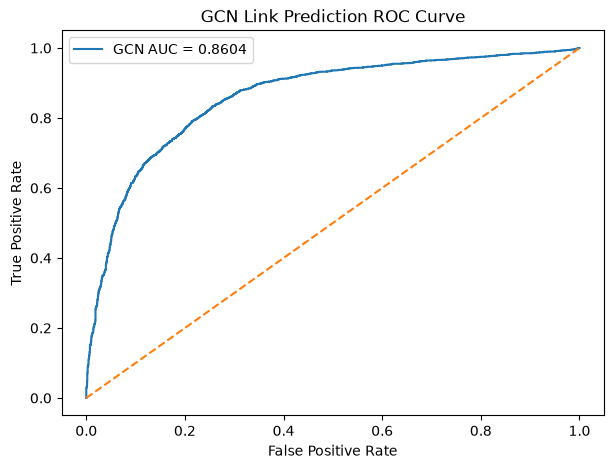

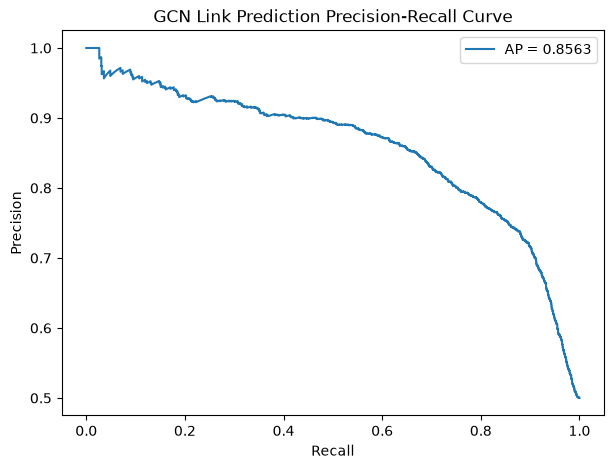

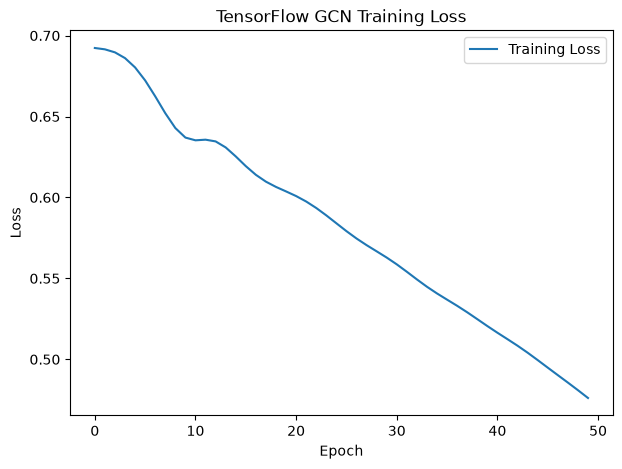

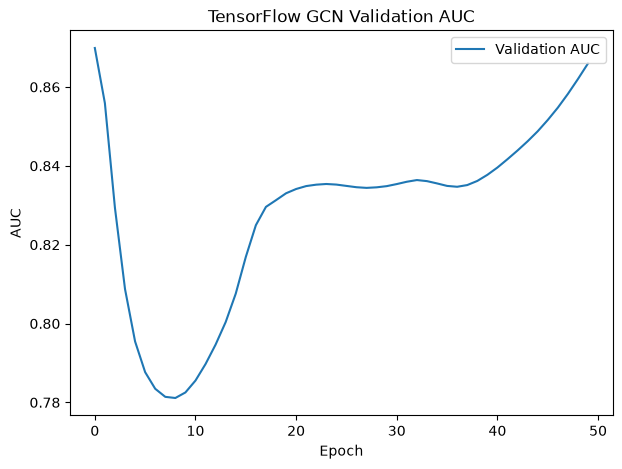

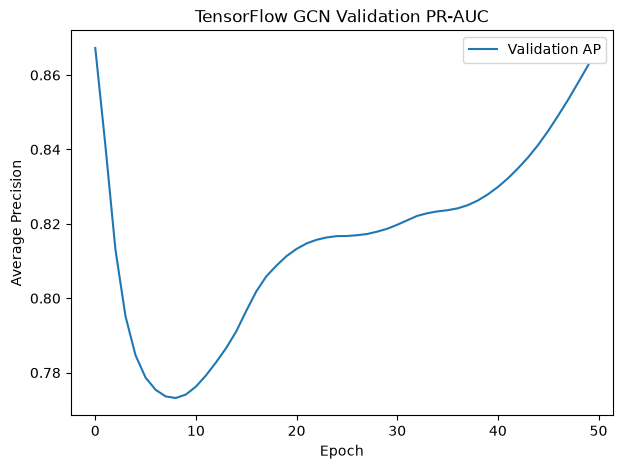


Best Validation Results
Best Epoch: 0
Best Validation AUC: 0.8699
Validation AP at Best Epoch: 0.8673
Test AUC: 0.8604
Test AP: 0.8563

Model saved: model\disease_gcn_tensorflow.weights.h5
Embeddings saved: model\disease_embeddings_tensorflow.npy


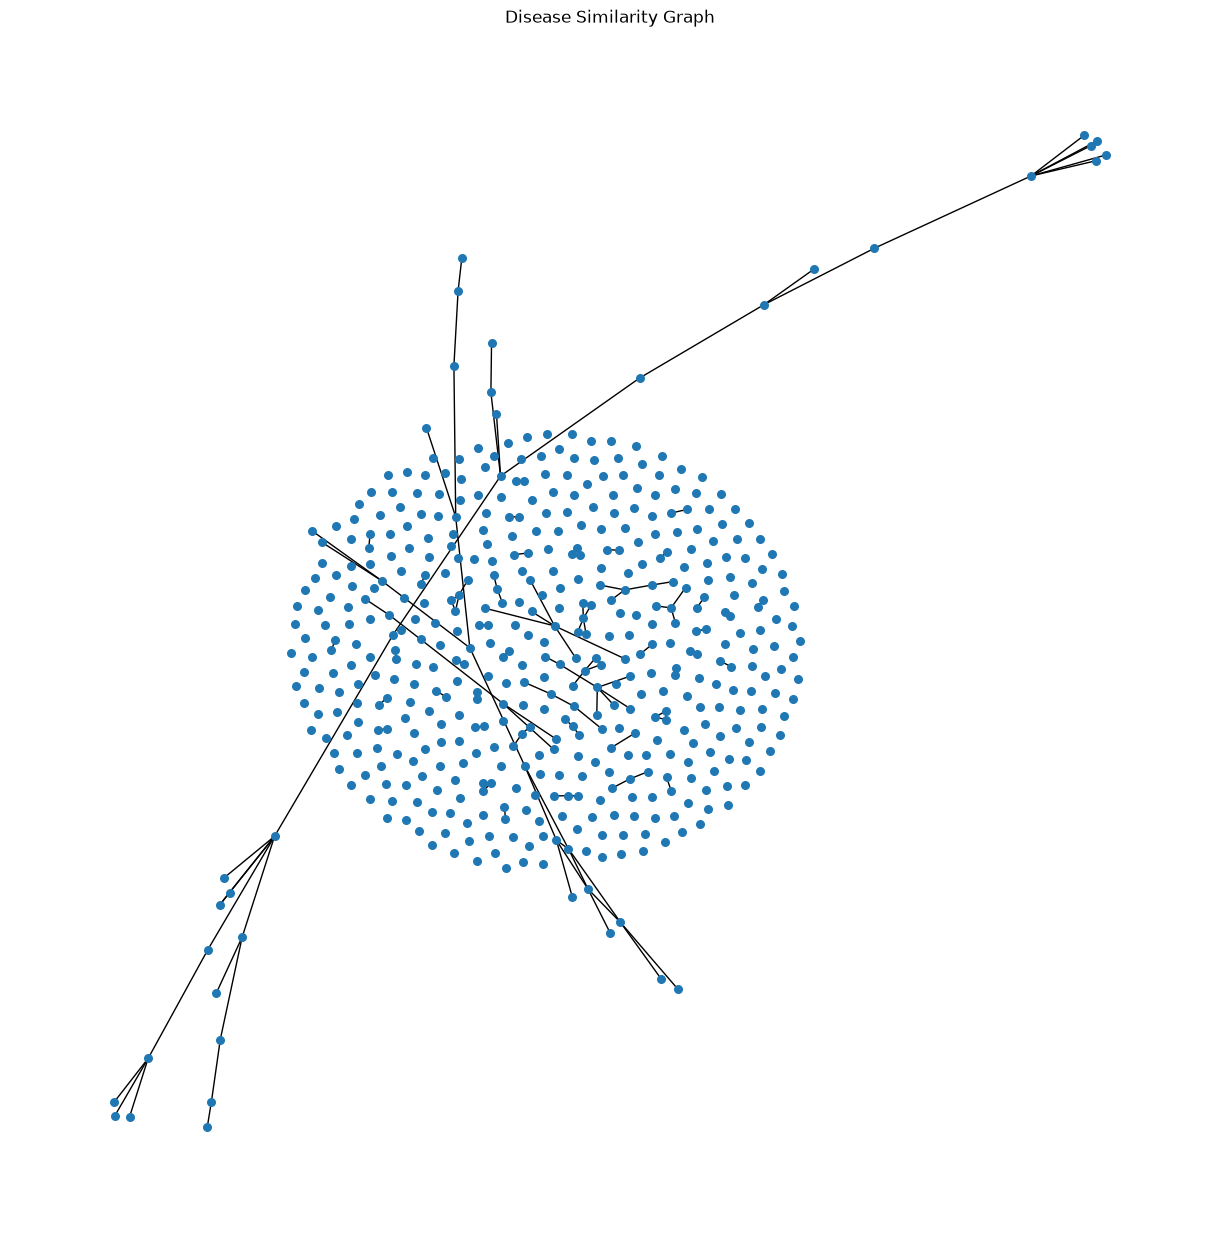


Target Disease: umls:C0011860 (Diabetes Mellitus, Type 2)

Top Related Diseases
1. umls:C0342277 (Diabetes Mellitus, Type Ii, Autosomal Dominant) - similarity: 0.9830
   Top genes:
      GCK (score: 1.0000)
2. umls:C0027773 (Nesidioblastosis) - similarity: 0.9825
   Top genes:
      KCNJ11 (score: 1.0000)
3. umls:C0020538 (Hypertension) - similarity: 0.9822
   Top genes:
      ACE (score: 1.0000)
      AGT (score: 1.0000)
      AGTR1 (score: 0.9130)
      REN (score: 0.9084)
      NOS3 (score: 0.8873)
4. umls:C0162557 (Liver Failure, Acute) - similarity: 0.9819
   Top genes:
      TNF (score: 1.0000)
      INS (score: 0.9705)
      GC (score: 0.6732)
      ATP7B (score: 0.6665)
      FAS (score: 0.6662)
5. umls:C3809928 (IMMUNODEFICIENCY, COMMON VARIABLE, 9) - similarity: 0.9815
   Top genes:
      PRKCD (score: 1.0000)
6. umls:C0022661 (Kidney Failure, Chronic) - similarity: 0.9815
   Top genes:
      TGFB1 (score: 1.0000)
      ADIPOQ (score: 0.9806)
      CYBA (score: 0.9301)
     

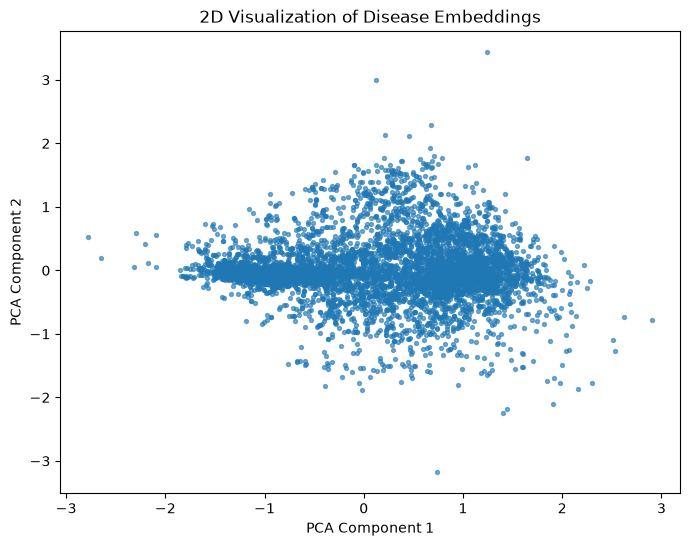

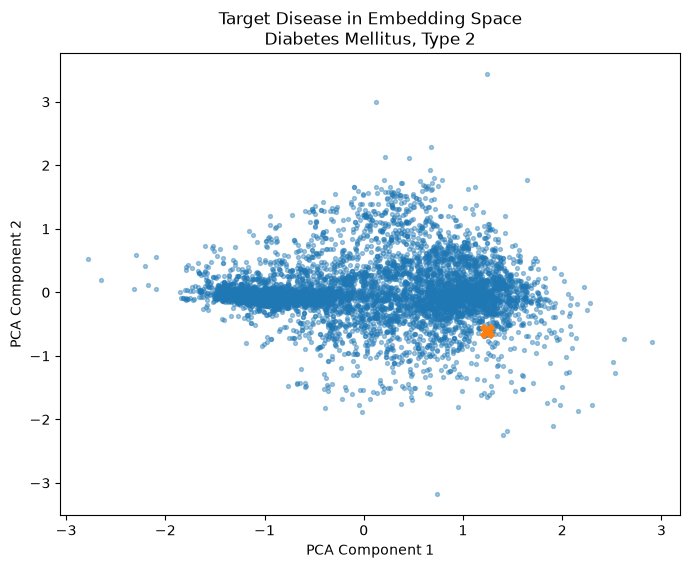


FINAL PROJECT SUMMARY
Diseases: 6761
Genes: 7878
Disease-gene associations: 26522
Disease graph edges: 24649
GCN hidden dimension: 128
Disease embedding dimension: 64
Training epochs: 50
Best Validation AUC: 0.8699
Test ROC-AUC: 0.8604
Test PR-AUC: 0.8563
Target disease: umls:C0011860
Target disease name: Diabetes Mellitus, Type 2

Generated Files
disease2idx.json: 0.15 MB
disease_embeddings_tensorflow.npy: 1.65 MB
disease_gcn_tensorflow.weights.h5: 3.89 MB
disease_gene_features.npy: 203.18 MB
edge_weights.npy: 0.09 MB
gene2idx.json: 0.11 MB
shared_gene_analysis.csv: 0.00 MB
test_edges.npy: 0.02 MB
top_related_diseases.csv: 0.00 MB
train_edges.npy: 0.15 MB
val_edges.npy: 0.02 MB


In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import networkx as nx

from tqdm import tqdm
from collections import defaultdict
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

DISGENET_FILE = "curated_gene_disease_associations.txt"
OUTPUT_DIR = "model"
K_NEIGHBORS = 10
HIDDEN_DIM = 128
EMBEDDING_DIM = 64
LEARNING_RATE = 0.001
EPOCHS = 50
SEED = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("Output directory:", OUTPUT_DIR)

feat_path = os.path.join(OUTPUT_DIR, "disease_gene_features.npy")
use_existing = os.path.exists(feat_path)
print("Found preprocessing?", use_existing)

if use_existing:
    print("Loading preprocessed files...")
    feat = np.load(feat_path)
    with open(os.path.join(OUTPUT_DIR, "disease2idx.json")) as f:
        disease2idx = json.load(f)
    with open(os.path.join(OUTPUT_DIR, "gene2idx.json")) as f:
        gene2idx = json.load(f)
    print("Diseases:", len(disease2idx))
    print("Genes:", len(gene2idx))
    print("Feature matrix:", feat.shape)
else:
    print("Running full preprocessing from raw DisGeNET...")
    df = pd.read_csv(DISGENET_FILE, sep="\t", dtype=str, low_memory=False)

    score_col = next((c for c in ["score", "Score", "score "] if c in df.columns), None)

    if score_col is None:
        for c in df.columns:
            try:
                df[c].astype(float)
                score_col = c
                break
            except:
                pass

    if score_col is None:
        raise ValueError("Score column not found.")

    df[score_col] = pd.to_numeric(df[score_col], errors="coerce")
    df = df.dropna(subset=["diseaseId", "geneSymbol", score_col])

    diseases = df["diseaseId"].unique().tolist()
    genes = df["geneSymbol"].unique().tolist()
    disease2idx = {d: i for i, d in enumerate(diseases)}
    gene2idx = {g: i for i, g in enumerate(genes)}

    N_d = len(diseases)
    N_g = len(genes)
    feat = np.zeros((N_d, N_g), dtype=np.float32)

    for _, r in tqdm(df.iterrows(), total=len(df)):
        di = disease2idx[r["diseaseId"]]
        gi = gene2idx[r["geneSymbol"]]
        score = float(r[score_col])
        if score > feat[di, gi]:
            feat[di, gi] = score

    row_max = feat.max(axis=1, keepdims=True)
    row_max[row_max == 0] = 1
    feat = feat / row_max

    np.save(feat_path, feat)

    with open(os.path.join(OUTPUT_DIR, "disease2idx.json"), "w") as f:
        json.dump(disease2idx, f)

    with open(os.path.join(OUTPUT_DIR, "gene2idx.json"), "w") as f:
        json.dump(gene2idx, f)

    print("Preprocessing finished.")

N_d, N_g = feat.shape

print("Number of diseases:", N_d)
print("Number of genes:", N_g)
print("Feature matrix shape:", feat.shape)

nonzero_associations = np.count_nonzero(feat)
genes_per_disease = np.count_nonzero(feat, axis=1)

print("\nDataset Statistics")
print("Diseases:", N_d)
print("Genes:", N_g)
print("Non-zero disease-gene associations:", nonzero_associations)
print("Average genes per disease:", f"{genes_per_disease.mean():.2f}")
print("Maximum genes per disease:", genes_per_disease.max())
print("Minimum genes per disease:", genes_per_disease.min())

print("\nBuilding disease similarity graph...")

nn = NearestNeighbors(n_neighbors=K_NEIGHBORS + 1, metric="cosine")
nn.fit(feat)
distances, indices = nn.kneighbors(feat)

u, v, w = [], [], []

for i in range(N_d):
    for idx, dist in zip(indices[i], distances[i]):
        if idx == i:
            continue
        similarity = 1.0 - dist
        if similarity > 0:
            u.append(i)
            v.append(idx)
            w.append(similarity)

u = np.array(u, dtype=np.int32)
v = np.array(v, dtype=np.int32)
w = np.array(w, dtype=np.float32)

edge_map = defaultdict(list)

for a, b, wt in zip(u, v, w):
    if a != b:
        x, y = (a, b) if a < b else (b, a)
        edge_map[(x, y)].append(float(wt))

u2, v2, w2 = [], [], []

for (a, b), weights in edge_map.items():
    u2.append(a)
    v2.append(b)
    w2.append(np.mean(weights))

u2 = np.array(u2, dtype=np.int32)
v2 = np.array(v2, dtype=np.int32)
w2 = np.array(w2, dtype=np.float32)

print("Number of unique undirected edges:", len(u2))

degrees = np.zeros(N_d, dtype=np.int32)

for a, b in zip(u2, v2):
    degrees[a] += 1
    degrees[b] += 1

print("\nGraph Statistics")
print("Nodes:", N_d)
print("Undirected edges:", len(u2))
print("Average degree:", f"{degrees.mean():.2f}")
print("Minimum degree:", degrees.min())
print("Maximum degree:", degrees.max())

all_edges = np.column_stack((u2, v2))
rng = np.random.default_rng(SEED)
all_edges = all_edges[rng.permutation(len(all_edges))]

num_edges = len(all_edges)
num_test = int(0.10 * num_edges)
num_val = int(0.10 * num_edges)
num_train = num_edges - num_val - num_test

train_edges = all_edges[:num_train]
val_edges = all_edges[num_train:num_train + num_val]
test_edges = all_edges[num_train + num_val:]

print("\nEdge Split")
print("Training edges:", len(train_edges))
print("Validation edges:", len(val_edges))
print("Test edges:", len(test_edges))

all_positive_edges = set()

for a, b in all_edges:
    all_positive_edges.add((int(a), int(b)))
    all_positive_edges.add((int(b), int(a)))

def generate_negative_edges(num_samples, num_nodes, positive_edges, seed=42):
    rng = np.random.default_rng(seed)
    negative_edges = set()

    while len(negative_edges) < num_samples:
        remaining = num_samples - len(negative_edges)
        src = rng.integers(0, num_nodes, size=remaining * 2)
        dst = rng.integers(0, num_nodes, size=remaining * 2)

        for a, b in zip(src, dst):
            a, b = int(a), int(b)

            if a == b or (a, b) in positive_edges:
                continue

            negative_edges.add((a, b))

            if len(negative_edges) >= num_samples:
                break

    return np.array(list(negative_edges), dtype=np.int32)

train_neg_edges = generate_negative_edges(len(train_edges), N_d, all_positive_edges, SEED)
val_neg_edges = generate_negative_edges(len(val_edges), N_d, all_positive_edges, SEED + 1)
test_neg_edges = generate_negative_edges(len(test_edges), N_d, all_positive_edges, SEED + 2)

def build_normalized_adjacency(edges, weights, num_nodes):
    sources, targets, values = [], [], []

    for (a, b), weight in zip(edges, weights):
        sources.extend([int(a), int(b)])
        targets.extend([int(b), int(a)])
        values.extend([float(weight), float(weight)])

    for i in range(num_nodes):
        sources.append(i)
        targets.append(i)
        values.append(1.0)

    sources = np.array(sources, dtype=np.int64)
    targets = np.array(targets, dtype=np.int64)
    values = np.array(values, dtype=np.float32)

    degree = np.zeros(num_nodes, dtype=np.float32)
    np.add.at(degree, sources, values)
    degree[degree == 0] = 1.0

    degree_inv_sqrt = 1.0 / np.sqrt(degree)
    values *= degree_inv_sqrt[sources] * degree_inv_sqrt[targets]

    adjacency = tf.sparse.SparseTensor(
        indices=np.column_stack((sources, targets)),
        values=values,
        dense_shape=[num_nodes, num_nodes]
    )

    return tf.sparse.reorder(adjacency)

weight_dictionary = {(int(a), int(b)): float(weight) for a, b, weight in zip(u2, v2, w2)}
train_weights = np.array([weight_dictionary[(int(a), int(b))] for a, b in train_edges], dtype=np.float32)

train_adjacency = build_normalized_adjacency(train_edges, train_weights, N_d)
print("\nTraining adjacency created.")

class GCNLayer(tf.keras.layers.Layer):
    def __init__(self, output_dim, activation=None):
        super().__init__()
        self.output_dim = output_dim
        self.activation = activation

    def build(self, input_shape):
        input_dim = int(input_shape[-1])
        self.weight = self.add_weight(shape=(input_dim, self.output_dim), initializer="glorot_uniform", trainable=True, name="weight")
        self.bias = self.add_weight(shape=(self.output_dim,), initializer="zeros", trainable=True, name="bias")

    def call(self, x, adjacency):
        output = tf.sparse.sparse_dense_matmul(adjacency, x)
        output = tf.matmul(output, self.weight) + self.bias

        if self.activation is not None:
            output = self.activation(output)

        return output

class DiseaseGCN(tf.keras.Model):
    def __init__(self, hidden_dim=128, embedding_dim=64):
        super().__init__()
        self.gcn1 = GCNLayer(hidden_dim, activation=tf.nn.relu)
        self.gcn2 = GCNLayer(embedding_dim)

    def call(self, x, adjacency):
        x = self.gcn1(x, adjacency)
        return self.gcn2(x, adjacency)

model = DiseaseGCN(HIDDEN_DIM, EMBEDDING_DIM)
x_tensor = tf.convert_to_tensor(feat, dtype=tf.float32)

_ = model(x_tensor, train_adjacency)

optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
loss_function = tf.keras.losses.BinaryCrossentropy(from_logits=True)

print("\nModel created.")
model.summary()

def edge_scores(embeddings, edges):
    edges = tf.convert_to_tensor(edges, dtype=tf.int32)
    source = tf.gather(embeddings, edges[:, 0])
    target = tf.gather(embeddings, edges[:, 1])
    return tf.reduce_sum(source * target, axis=1)

train_positive = train_edges
train_negative = train_neg_edges
val_positive = val_edges
val_negative = val_neg_edges
test_positive = test_edges
test_negative = test_neg_edges

loss_list = []
val_auc_list = []
val_ap_list = []

print("\nStarting GCN training...")

for epoch in range(EPOCHS):
    with tf.GradientTape() as tape:
        embeddings = model(x_tensor, train_adjacency, training=True)
        positive_scores = edge_scores(embeddings, train_positive)
        negative_scores = edge_scores(embeddings, train_negative)

        train_scores = tf.concat([positive_scores, negative_scores], axis=0)
        train_labels = tf.concat([tf.ones_like(positive_scores), tf.zeros_like(negative_scores)], axis=0)

        loss = loss_function(train_labels, train_scores)

    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    validation_embeddings = model(x_tensor, train_adjacency, training=False)
    val_positive_scores = edge_scores(validation_embeddings, val_positive)
    val_negative_scores = edge_scores(validation_embeddings, val_negative)

    val_scores = np.concatenate([val_positive_scores.numpy(), val_negative_scores.numpy()])
    val_labels = np.concatenate([np.ones(len(val_positive)), np.zeros(len(val_negative))])

    val_auc = roc_auc_score(val_labels, val_scores)
    val_ap = average_precision_score(val_labels, val_scores)

    loss_list.append(float(loss.numpy()))
    val_auc_list.append(float(val_auc))
    val_ap_list.append(float(val_ap))

    if epoch % 5 == 0:
        print(f"Epoch {epoch}/{EPOCHS} - Loss: {loss.numpy():.4f} - Val AUC: {val_auc:.4f} - Val AP: {val_ap:.4f}")

final_embeddings = model(x_tensor, train_adjacency, training=False)

test_positive_scores = edge_scores(final_embeddings, test_positive)
test_negative_scores = edge_scores(final_embeddings, test_negative)

test_scores = np.concatenate([test_positive_scores.numpy(), test_negative_scores.numpy()])
test_labels = np.concatenate([np.ones(len(test_positive)), np.zeros(len(test_negative))])

test_auc = roc_auc_score(test_labels, test_scores)
test_ap = average_precision_score(test_labels, test_scores)

print("\nFinal Test Results")
print("Test ROC-AUC:", f"{test_auc:.4f}")
print("Test PR-AUC / Average Precision:", f"{test_ap:.4f}")

fpr, tpr, _ = roc_curve(test_labels, test_scores)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"GCN AUC = {test_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("GCN Link Prediction ROC Curve")
plt.legend()
plt.show()

precision, recall, _ = precision_recall_curve(test_labels, test_scores)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"AP = {test_ap:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("GCN Link Prediction Precision-Recall Curve")
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(loss_list, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("TensorFlow GCN Training Loss")
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(val_auc_list, label="Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("TensorFlow GCN Validation AUC")
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(val_ap_list, label="Validation AP")
plt.xlabel("Epoch")
plt.ylabel("Average Precision")
plt.title("TensorFlow GCN Validation PR-AUC")
plt.legend()
plt.show()

best_epoch = int(np.argmax(val_auc_list))
best_val_auc = val_auc_list[best_epoch]
best_val_ap = val_ap_list[best_epoch]

print("\nBest Validation Results")
print("Best Epoch:", best_epoch)
print("Best Validation AUC:", f"{best_val_auc:.4f}")
print("Validation AP at Best Epoch:", f"{best_val_ap:.4f}")
print("Test AUC:", f"{test_auc:.4f}")
print("Test AP:", f"{test_ap:.4f}")

MODEL_PATH = os.path.join(OUTPUT_DIR, "disease_gcn_tensorflow.weights.h5")
EMBEDDING_PATH = os.path.join(OUTPUT_DIR, "disease_embeddings_tensorflow.npy")

model.save_weights(MODEL_PATH)
np.save(EMBEDDING_PATH, final_embeddings.numpy())

print("\nModel saved:", MODEL_PATH)
print("Embeddings saved:", EMBEDDING_PATH)

np.save(os.path.join(OUTPUT_DIR, "train_edges.npy"), train_edges)
np.save(os.path.join(OUTPUT_DIR, "val_edges.npy"), val_edges)
np.save(os.path.join(OUTPUT_DIR, "test_edges.npy"), test_edges)
np.save(os.path.join(OUTPUT_DIR, "edge_weights.npy"), w2)

G = nx.Graph()
G.add_nodes_from(range(N_d))

for a, b, weight in zip(u2, v2, w2):
    G.add_edge(int(a), int(b), weight=float(weight))

MAX_NODES_TO_PLOT = 500

if N_d > MAX_NODES_TO_PLOT:
    rng = np.random.default_rng(SEED)
    selected_nodes = set(rng.choice(N_d, size=MAX_NODES_TO_PLOT, replace=False).tolist())
    G_plot = G.subgraph(selected_nodes).copy()
else:
    G_plot = G

plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G_plot, seed=42)
nx.draw(G_plot, pos, node_size=30, with_labels=False)
plt.title("Disease Similarity Graph")
plt.show()

with open(os.path.join(OUTPUT_DIR, "disease2idx.json")) as f:
    disease2idx = json.load(f)

with open(os.path.join(OUTPUT_DIR, "gene2idx.json")) as f:
    gene2idx = json.load(f)

idx2disease = {int(v): k for k, v in disease2idx.items()}
idx2gene = {int(v): k for k, v in gene2idx.items()}

df = pd.read_csv(DISGENET_FILE, sep="\t", dtype=str, low_memory=False)
disease_names_map = df.drop_duplicates("diseaseId").set_index("diseaseId")["diseaseName"].to_dict()

embeddings_np = final_embeddings.numpy()

def get_top_comorbid_diseases_with_genes(disease_id, top_k_diseases=10, top_k_genes=5):
    if disease_id not in disease2idx:
        raise ValueError(f"Disease {disease_id} not found in the graph!")

    node_idx = int(disease2idx[disease_id])
    disease_embedding = embeddings_np[node_idx].reshape(1, -1)
    similarities = cosine_similarity(disease_embedding, embeddings_np).flatten()
    similarities[node_idx] = -1

    top_indices = similarities.argsort()[-top_k_diseases:][::-1]
    top_comorbid_info = []

    for idx in top_indices:
        idx = int(idx)
        comorb_disease_id = idx2disease[idx]
        similarity_score = similarities[idx]
        disease_name = disease_names_map.get(comorb_disease_id, "Unknown")

        gene_scores = feat[idx]
        nonzero_indices = np.where(gene_scores > 0)[0]

        if len(nonzero_indices) > 0:
            sorted_indices = nonzero_indices[np.argsort(gene_scores[nonzero_indices])[-top_k_genes:][::-1]]
        else:
            sorted_indices = []

        top_genes = [(idx2gene[int(g)], float(gene_scores[g])) for g in sorted_indices]

        top_comorbid_info.append({
            "disease_id": comorb_disease_id,
            "disease_name": disease_name,
            "similarity": float(similarity_score),
            "top_genes": top_genes
        })

    return top_comorbid_info

target_disease = "umls:C0011860"

top_comorbid = get_top_comorbid_diseases_with_genes(target_disease, top_k_diseases=10, top_k_genes=5)

target_name = disease_names_map.get(target_disease, "Unknown")

print("\nTarget Disease:", target_disease, f"({target_name})")
print("\nTop Related Diseases")

for rank, comorb in enumerate(top_comorbid, start=1):
    print(f"{rank}. {comorb['disease_id']} ({comorb['disease_name']}) - similarity: {comorb['similarity']:.4f}")

    if comorb["top_genes"]:
        print("   Top genes:")
        for gene, score in comorb["top_genes"]:
            print(f"      {gene} (score: {score:.4f})")
    else:
        print("   No non-zero genes found.")

result_rows = []

for rank, comorb in enumerate(top_comorbid, start=1):
    genes_string = ", ".join(gene for gene, score in comorb["top_genes"])

    result_rows.append({
        "Rank": rank,
        "Disease ID": comorb["disease_id"],
        "Disease": comorb["disease_name"],
        "Similarity": comorb["similarity"],
        "Top Genes": genes_string
    })

result_df = pd.DataFrame(result_rows)

print("\n", result_df.to_string(index=False))

result_df.to_csv(os.path.join(OUTPUT_DIR, "top_related_diseases.csv"), index=False)
print("Prediction results saved.")

def get_disease_genes(disease_id):
    if disease_id not in disease2idx:
        return set()

    idx = int(disease2idx[disease_id])
    gene_indices = np.where(feat[idx] > 0)[0]
    return {idx2gene[int(i)] for i in gene_indices}

def get_shared_genes(disease_a, disease_b):
    return get_disease_genes(disease_a).intersection(get_disease_genes(disease_b))

print("\nShared Genes With Target Disease")

shared_gene_rows = []

for rank, comorb in enumerate(top_comorbid, start=1):
    disease_id = comorb["disease_id"]
    shared_genes = get_shared_genes(target_disease, disease_id)

    shared_gene_rows.append({
        "Rank": rank,
        "Disease": comorb["disease_name"],
        "Similarity": comorb["similarity"],
        "Shared Gene Count": len(shared_genes),
        "Shared Genes": ", ".join(sorted(shared_genes))
    })

    print(f"\n{rank}. {comorb['disease_name']}")
    print("Similarity:", f"{comorb['similarity']:.4f}")
    print("Shared genes:", len(shared_genes))
    print(", ".join(sorted(shared_genes)) if shared_genes else "No directly shared genes.")

shared_gene_df = pd.DataFrame(shared_gene_rows)
shared_gene_df.to_csv(os.path.join(OUTPUT_DIR, "shared_gene_analysis.csv"), index=False)

print("\nShared-gene analysis saved.")

pca = PCA(n_components=2, random_state=SEED)
embedding_2d = pca.fit_transform(embeddings_np)

plt.figure(figsize=(8, 6))
plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], s=8, alpha=0.6)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("2D Visualization of Disease Embeddings")
plt.show()

target_idx = int(disease2idx[target_disease])

plt.figure(figsize=(8, 6))
plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], s=8, alpha=0.4)
plt.scatter(embedding_2d[target_idx, 0], embedding_2d[target_idx, 1], s=100, marker="X")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title(f"Target Disease in Embedding Space\n{target_name}")
plt.show()

print("\nFINAL PROJECT SUMMARY")
print("Diseases:", N_d)
print("Genes:", N_g)
print("Disease-gene associations:", nonzero_associations)
print("Disease graph edges:", len(u2))
print("GCN hidden dimension:", HIDDEN_DIM)
print("Disease embedding dimension:", EMBEDDING_DIM)
print("Training epochs:", EPOCHS)
print("Best Validation AUC:", f"{best_val_auc:.4f}")
print("Test ROC-AUC:", f"{test_auc:.4f}")
print("Test PR-AUC:", f"{test_ap:.4f}")
print("Target disease:", target_disease)
print("Target disease name:", target_name)

print("\nGenerated Files")

for filename in sorted(os.listdir(OUTPUT_DIR)):
    filepath = os.path.join(OUTPUT_DIR, filename)
    if os.path.isfile(filepath):
        size_mb = os.path.getsize(filepath) / (1024 * 1024)
        print(f"{filename}: {size_mb:.2f} MB")